In [1]:
# All the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, hamming_loss, f1_score
from scipy.sparse import csr_matrix, hstack

# Load the card data
df = pd.read_csv("cards.csv.gz", compression="gzip")

# Select columns with features
cols = ["text", "manaCost", "manaValue", "type", "types", "colorIdentity"]
df = df[cols].copy()

/var/folders/dk/lhggss1138b7t9bhsm7r4y2h0000gn/T/ipykernel_84956/982503008.py:20: DtypeWarning: Columns (0: faceFlavorName, 1: facePrintedName, 2: hasContentWarning, 3: loyalty) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cards.csv.gz", compression="gzip")


In [2]:
# Cleaning data
def parse_colors(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [c.strip() for c in str(x).split(",")]

df["colors"] = df["colorIdentity"].apply(parse_colors)
mlb = MultiLabelBinarizer(classes=['W','U','B','R','G'])
y = mlb.fit_transform(df["colors"])

# features extraction
#Combine text fields
df["combined_text"] = (
    df["text"].fillna("") + " " +
    df["type"].fillna("") + " " +
    df["types"].fillna("")
)

# Mana symbol counts
def count_symbol(cost, symbol):
    if pd.isna(cost):
        return 0
    return str(cost).count("{" + symbol + "}")

df["manaValue"] = df["manaValue"].fillna(0)
num_cols = ["manaValue"]

# Fill missing numeric values with NAs
df["manaValue"] = df["manaValue"].fillna(0)



# Training/testing split 90/10
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y,
    test_size=0.1,
    random_state=42
)


# TFID vectorizer
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    stop_words="english"
)
X_text_train = tfidf.fit_transform(X_train_df["combined_text"])
X_text_test  = tfidf.transform(X_test_df["combined_text"])


# Number features
X_num_train = csr_matrix(X_train_df[num_cols].values)
X_num_test  = csr_matrix(X_test_df[num_cols].values)






# Combining features
#X_train = hstack([X_text_train, X_num_train])
#X_test  = hstack([X_text_test, X_num_test])
X_train = X_text_train
X_test = X_text_test

In [3]:
# Model training
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced")
)

model.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

Accuracy on training set = 0.6627431994916639
Accuracy on testing set = 0.6378324407733503
F1 score = 0.7971715415965758


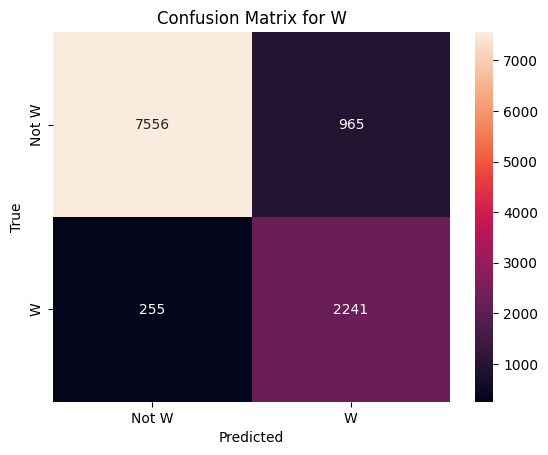

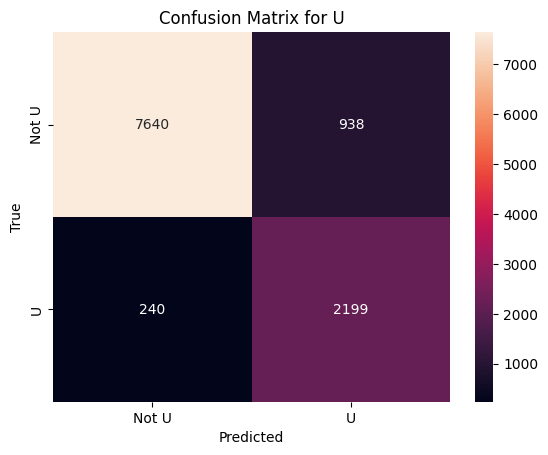

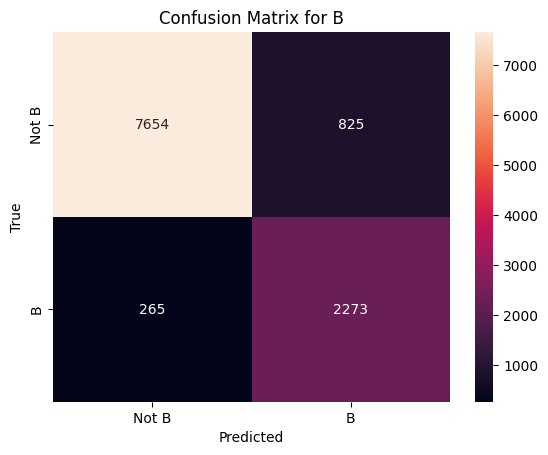

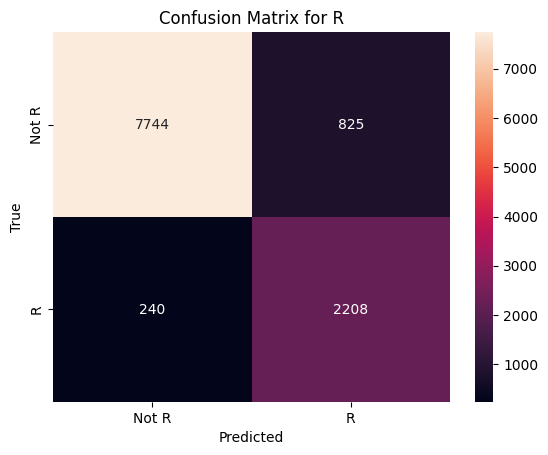

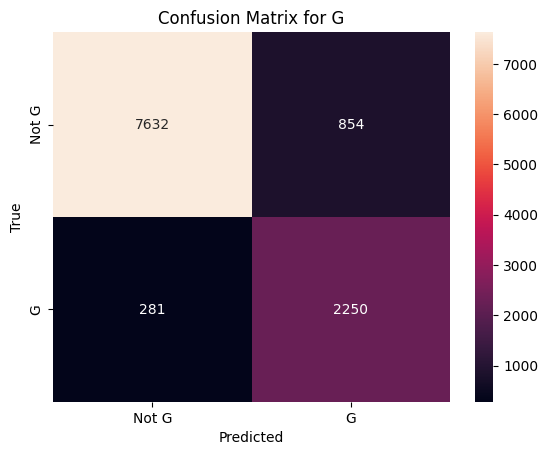

In [4]:


# model predictions
Y_train_pred = model.predict(X_train)
Y_test_pred  = model.predict(X_test)

print("Accuracy on training set =", accuracy_score(y_train, Y_train_pred))
print("Accuracy on testing set =", accuracy_score(y_test, Y_test_pred))
print("F1 score =", f1_score(y_test, Y_test_pred, average='weighted'))


#Confusion matrices
mcm = multilabel_confusion_matrix(y_test, Y_test_pred)

labels = ['W','U','B','R','G']

# Plot one heatmap per color
for i, label in enumerate(labels):
    plt.figure()
    
    sns.heatmap(
        mcm[i],
        annot=True,
        fmt='d',
        xticklabels=['Not ' + label, label],
        yticklabels=['Not ' + label, label]
    )
    
    plt.title(f'Confusion Matrix for {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

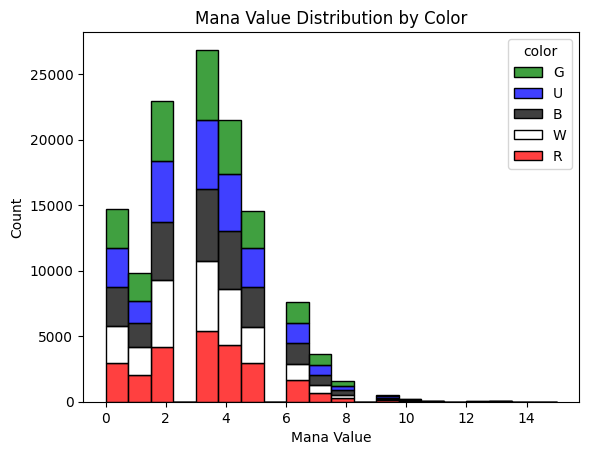

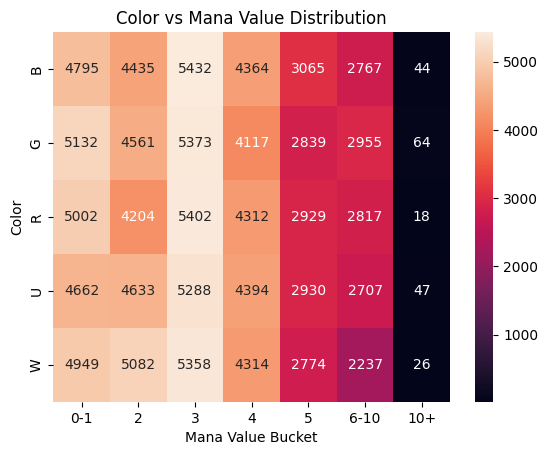

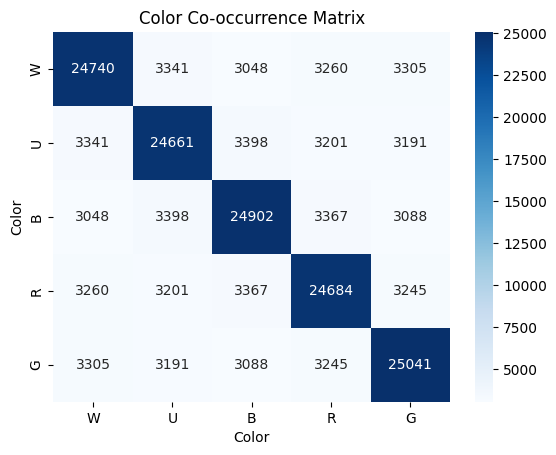


Top words for W:
['add land', 'angel', 'soldier', 'enchantment card', 'add artifact', 'exile target', 'lifelink', 'white', 'vigilance', 'plains']

Top words for U:
['island land', 'target spell', 'merfolk', 'creature merfolk', 'wizard', 'draw', 'blue', 'add artifact', 'flying', 'island']

Top words for B:
['creature zombie', 'life', 'add artifact', 'demon', 'loses life', 'menace', 'lose life', 'black', 'deathtouch', 'swamp']

Top words for R:
['add artifact', 'block turn', 'deals', 'add', 'deals damage', 'damage target', 'red', 'creature goblin', 'mountain', 'haste']

Top words for G:
['target artifact', 'creature elf', 'land cards', 'creature flying', 'elf', 'reach', 'land card', 'trample', 'forest', 'green']


In [5]:
# PLOT 1 (mana cost per colour distribution)
rows = []
for _, row in df.iterrows():
    for c in row["colors"]:
        rows.append({
            "color": c,
            "manaValue": row["manaValue"]
        })
df_expanded = pd.DataFrame(rows)
# maps colour to the correct visual
colour_map = {
    "R": "red",
    "G": "green",
    "B": "black",
    "W": "white",
    "U": "blue"
}
plt.figure()
sns.histplot(
    data=df_expanded,
    x="manaValue",
    hue="color",
    bins=20,
    multiple="stack",
    palette=colour_map
)
plt.title("Mana Value Distribution by Color")
plt.xlabel("Mana Value")
plt.ylabel("Count")
plt.show()


# PLOT 2 (mana cost heatmap)
df_expanded["mana_bucket"] = pd.cut(
    df_expanded["manaValue"],
    bins=[-1,1,2,3,4,5,10,100],
    labels=["0-1","2","3","4","5","6-10","10+"]
)
pivot = pd.crosstab(
    df_expanded["color"],
    df_expanded["mana_bucket"]
)
plt.figure()
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Color vs Mana Value Distribution")
plt.xlabel("Mana Value Bucket")
plt.ylabel("Color")
plt.show()


# PLOT 3 (Mana colour groupings)
colors = ['W','U','B','R','G']
co_matrix = pd.DataFrame(0, index=colors, columns=colors)
for card_colors in df["colors"]:
    for c1 in card_colors:
        for c2 in card_colors:
            co_matrix.loc[c1, c2] += 1
plt.figure()
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Color Co-occurrence Matrix")
plt.xlabel("Color")
plt.ylabel("Color")
plt.show()

#Plot 4 (Common words per colour)
feature_names = tfidf.get_feature_names_out()

for i, color in enumerate(['W','U','B','R','G']):
    coef = model.estimators_[i].coef_[0]
    top_idx = np.argsort(coef)[-10:]
    print(f"\nTop words for {color}:")
    print([feature_names[j] for j in top_idx])

In [6]:
# Evaluation
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=mlb.classes_))


# Prediction
def predict_card(text, mana_cost, mana_value, type_input):
    combined = text + " " + type_input
    
    X_text_new = tfidf.transform([combined])
    
    # no numeric features
    pred = model.predict(X_text_new)
    
    return mlb.inverse_transform(pred)


# Predict a card
print("\nExample Prediction")
print(predict_card(
    "Destroy target creature",
    "{1}{1}",
    2,
    "Instant"
))

Classification Report
              precision    recall  f1-score   support

           W       0.70      0.90      0.79      2496
           U       0.70      0.90      0.79      2439
           B       0.73      0.90      0.81      2538
           R       0.73      0.90      0.81      2448
           G       0.72      0.89      0.80      2531

   micro avg       0.72      0.90      0.80     12452
   macro avg       0.72      0.90      0.80     12452
weighted avg       0.72      0.90      0.80     12452
 samples avg       0.71      0.81      0.74     12452


Example Prediction
[('B',)]


/Users/metamud/Downloads/506 Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/metamud/Downloads/506 Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/metamud/Downloads/506 Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, m